# Extraccion de caracteristicas

In [1]:
# Cargar los datos transformados
import os
from os import path
import numpy as np
from pathlib import Path

STFT_PATH = './data/tf_representations/stft.npz'
CWT_PATH  = './data/tf_representations/cwt.npz'
#GSP_PATH  = './data/tf_representations/gsp.npz'

CHANNELS   = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
TARGET_COL = 'eyeDetection'  # 0: ojos abiertos, 1: ojos cerrados

#lista = [('STFT', STFT_PATH), ('CWT', CWT_PATH), ('GSP', GSP_PATH)]
lista = [('STFT', STFT_PATH), ('CWT', CWT_PATH)]

for label, fpath in lista:
    if not path.exists(fpath):
        raise FileNotFoundError(f"El archivo no existe: {fpath}")
    else:
        print(f"Los datos {label} ya existen en {fpath}")

stft = np.load(STFT_PATH)
cwt  = np.load(CWT_PATH)
#gsp  = np.load(GSP_PATH, allow_pickle=True)

print(f"\nSTFT — Shape por canal : {stft['O2'].shape}  |  Canales: {len(CHANNELS)}")
print(f"CWT  — Shape por canal : {cwt['O2'].shape}   |  Canales: {len(CHANNELS)}")
#print(f"GSP  — Shape espectrograma: {gsp['spectrogram'].shape}  (modos × tiempo)")

print(f"\nLabels STFT: {stft['labels'].shape}  |  Clases: {np.unique(stft['labels'])}")
print(f"Labels CWT : {cwt['labels'].shape}   |  Clases: {np.unique(cwt['labels'])}")
#print(f"Labels GSP : {gsp['labels'].shape}   |  Clases: {np.unique(gsp['labels'])}")

Los datos STFT ya existen en ./data/tf_representations/stft.npz
Los datos CWT ya existen en ./data/tf_representations/cwt.npz

STFT — Shape por canal : (73, 236)  |  Canales: 14
CWT  — Shape por canal : (80, 14980)   |  Canales: 14

Labels STFT: (236,)  |  Clases: [0. 1.]
Labels CWT : (14980,)   |  Clases: [0 1]


## Consideraciones y definiciones iniciales

- **Alineación temporal**: La STFT ya tiene sus propias ventanas de 2s (~232 ventanas en stft_times). Para que la comparación sea justa, la CWT debe analizar exactamente los mismos segmentos temporales. Para cada ventana STFT centrada en t_i, calculo los índices de muestra correspondientes en la CWT y promedio la potencia en ese eje temporal, obteniendo un espectro promedio (80,). Ambas representaciones producen así el mismo número de instancias con las mismas etiquetas.
- **Integración trapezoidal**: Las frecuencias de la STFT son linealmente espaciadas y las de la CWT son log-espaciadas. Si sumamos directamente los valores de potencia sin ponderar vamos a sobrepasar las frecuencias bajas en la CWT. `np.trapezoid(power, freqs)` maneja ambos casos correctamente.
- **Origen de frecuencias CWT**: Según como se construyeron las escalas en el notebook anterior, las frecuencias de la CWT pueden estar en orden descendente. Hay una función auxiliar que lo detecta y corrige antes de integrar.

## Decisiones de diseño — extracción de features

### Features seleccionadas (4 por canal × 14 canales = 56 features)

Para cada ventana temporal y cada canal EEG se extraen cuatro características
desde el espectro de potencia promediado:

1. **Potencia alfa absoluta** (`alpha_abs`): integral trapezoidal de la densidad
   de potencia en 8–13 Hz. Cuantifica la energía bruta del ritmo alfa. Se usa
   integración trapezoidal (`np.trapz`) en lugar de suma directa para manejar
   correctamente frecuencias no uniformemente espaciadas (CWT log-espaciada).

2. **Potencia alfa relativa** (`alpha_rel`): cociente entre la potencia alfa y la
   potencia total en 4–40 Hz. Al normalizar por la potencia total, esta feature
   es invariante a diferencias de amplitud entre sujetos y sesiones — un requisito
   importante para comparaciones justas entre técnicas TF con distintas unidades.

3. **Entropía espectral de Shannon normalizada** (`entropy`): mide cuán
   concentrada está la energía en el espectro completo (4–40 Hz). Un valor bajo
   indica que la energía se concentra en pocas frecuencias (ej. alfa dominante);
   un valor alto indica distribución uniforme (ausencia de ritmo dominante).
   Se normaliza por `log2(N)` para que el rango sea siempre [0, 1]
   independientemente del número de bins de frecuencia.

4. **Centro de gravedad alfa** (`cog`): media ponderada de las frecuencias en
   8–13 Hz, con la potencia como peso — método de Klimesch (1999). Más robusto
   que el pico máximo porque no asume que el alfa tiene un único pico, lo cual
   no siempre se cumple empíricamente.

### Rango de frecuencias

Ambas representaciones cubren 4–40 Hz, alineado con el filtro pasa-banda
aplicado en el preprocesamiento. La banda delta (< 4 Hz) se excluye porque
no es relevante para la tarea de ojos abiertos/cerrados.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# ------------------------- CONSTANTES -------------------------
# --------------------------------------------------------------

FS       = 128    # Hz
ALPHA_LO = 8.0    # Hz — límite inferior banda alfa
ALPHA_HI = 13.0   # Hz — límite superior banda alfa
WIN_SEC  = 2.0    # s  — largo de ventana (idéntico al de la STFT)

### Funciones de Extracción

In [3]:
def _sort_asc(power, freqs):
    """Reordena ascendentemente si las frecuencias vienen descendentes (CWT)."""
    if freqs[0] > freqs[-1]:
        idx = np.argsort(freqs)
        return power[idx], freqs[idx]
    return power, freqs


def alpha_power_abs(power, freqs):
    """Potencia absoluta en la banda alfa (integración trapezoidal)."""
    p, f = _sort_asc(power, freqs)
    mask = (f >= ALPHA_LO) & (f <= ALPHA_HI)
    if mask.sum() < 2:
        return 0.0
    return float(np.trapezoid(p[mask], f[mask]))


def alpha_power_rel(power, freqs):
    """Potencia relativa: alfa / total (4-40 Hz). Invariante a escala de amplitud."""
    p, f = _sort_asc(power, freqs)
    p_alpha = alpha_power_abs(p, f)
    p_total = float(np.trapezoid(p, f))
    return p_alpha / p_total if p_total > 0 else 0.0


def spectral_entropy(power):
    """
    Entropía espectral de Shannon normalizada.
    0 → energía concentrada en pocas frecuencias (ej. alfa dominante).
    1 → energía distribuida uniformemente.
    """
    total = power.sum()
    if total <= 0:
        return 0.0
    p = power / total
    p = p[p > 0]                        # evitar log(0)
    H     = -np.sum(p * np.log2(p))
    H_max = np.log2(len(power))         # entropía máxima (distribución uniforme)
    return float(H / H_max) if H_max > 0 else 0.0


def alpha_cog(power, freqs):
    """
    Centro de gravedad (CoG) en la banda alfa — método Klimesch (1999).
    Más robusto que el pico máximo cuando hay picos dobles o ambiguos.
    """
    p, f = _sort_asc(power, freqs)
    mask   = (f >= ALPHA_LO) & (f <= ALPHA_HI)
    p_band = p[mask]
    f_band = f[mask]
    denom  = p_band.sum()
    return float(np.sum(f_band * p_band) / denom) if denom > 0 else (ALPHA_LO + ALPHA_HI) / 2.0

## Extracción

### Ventanas

Se heredan las ~232 ventanas de 2 s ya calculadas por la STFT (solapamiento
del 75%, ventana Hann). Para la CWT, se identifica el segmento de muestras
correspondiente a cada ventana STFT y se promedia la potencia en el eje
temporal, obteniendo un espectro representativo de dimensión `(n_freqs,)`.
Esto garantiza que ambas técnicas producen exactamente el mismo número de
instancias con los mismos límites temporales, condición necesaria para que
la comparación sea justa.

### Etiquetado por centro

A cada ventana se le asigna la etiqueta del sample más cercano a su centro
temporal. Esta estrategia es simple, reproducible y suficientemente precisa
para este dataset, donde las transiciones entre estados son lentas relativas
al largo de la ventana (2 s).

### Solapamiento y evaluación posterior

El solapamiento del 75% genera muestras temporalmente dependientes: ventanas
consecutivas comparten 1.5 s de señal. Por esta razón, en el notebook de
clasificación **no se usará un split aleatorio** — se aplicará un split
temporal por bloques (primeros ~80 s para entrenamiento, últimos ~37 s para
test) para evitar data leakage entre conjuntos.

### STFT

In [4]:
stft_freqs  = stft['freqs']     # (n_stft_freqs,)  frecuencias en Hz
stft_times  = stft['times']     # (n_windows,)     tiempo en s de cada ventana
stft_labels = stft['labels']    # (n_windows,)     etiqueta 0/1

FEAT_NAMES = ['alpha_abs', 'alpha_rel', 'entropy', 'cog']
COL_NAMES  = [f'{ch}_{f}' for ch in CHANNELS for f in FEAT_NAMES]

rows = []
for j in range(len(stft_times)):
    row = {}
    for ch in CHANNELS:
        spectrum = stft[ch][:, j]
        row[f'{ch}_alpha_abs'] = alpha_power_abs(spectrum, stft_freqs)
        row[f'{ch}_alpha_rel'] = alpha_power_rel(spectrum, stft_freqs)
        row[f'{ch}_entropy']   = spectral_entropy(spectrum)
        row[f'{ch}_cog']       = alpha_cog(spectrum, stft_freqs)
    rows.append(row)

df_stft_feat = pd.DataFrame(rows, columns=COL_NAMES)
df_stft_feat['label'] = stft_labels.astype(int)

print(f"STFT — shape: {df_stft_feat.shape}")
print(f"  NaN: {df_stft_feat.isnull().sum().sum()}")
print(f"  Clases: {df_stft_feat['label'].value_counts().to_dict()}")

STFT — shape: (236, 57)
  NaN: 0
  Clases: {0: 128, 1: 108}


### CWT

In [5]:
cwt_freqs  = cwt['freqs']
n_cwt_samp = cwt['O2'].shape[1]   # = 14 980

rows = []
for j, t_center in enumerate(stft_times):

    # Índices de muestra CWT correspondientes a esta ventana STFT
    idx_start = max(0,              int(np.round((t_center - WIN_SEC / 2) * FS)))
    idx_end   = min(n_cwt_samp - 1, int(np.round((t_center + WIN_SEC / 2) * FS)))

    row = {}
    for ch in CHANNELS:
        # Promedio temporal dentro de la ventana → espectro (n_freqs,)
        segment  = cwt[ch][:, idx_start : idx_end + 1]
        spectrum = segment.mean(axis=1)

        row[f'{ch}_alpha_abs'] = alpha_power_abs(spectrum, cwt_freqs)
        row[f'{ch}_alpha_rel'] = alpha_power_rel(spectrum, cwt_freqs)
        row[f'{ch}_entropy']   = spectral_entropy(spectrum)
        row[f'{ch}_cog']       = alpha_cog(spectrum, cwt_freqs)
    rows.append(row)

df_cwt_feat = pd.DataFrame(rows, columns=COL_NAMES)
df_cwt_feat['label'] = stft_labels.astype(int)   # mismas ventanas → mismas etiquetas

print(f"CWT — shape: {df_cwt_feat.shape}")
print(f"  NaN: {df_cwt_feat.isnull().sum().sum()}")
print(f"  Clases: {df_cwt_feat['label'].value_counts().to_dict()}")

CWT — shape: (236, 57)
  NaN: 0
  Clases: {0: 128, 1: 108}


## Revisión

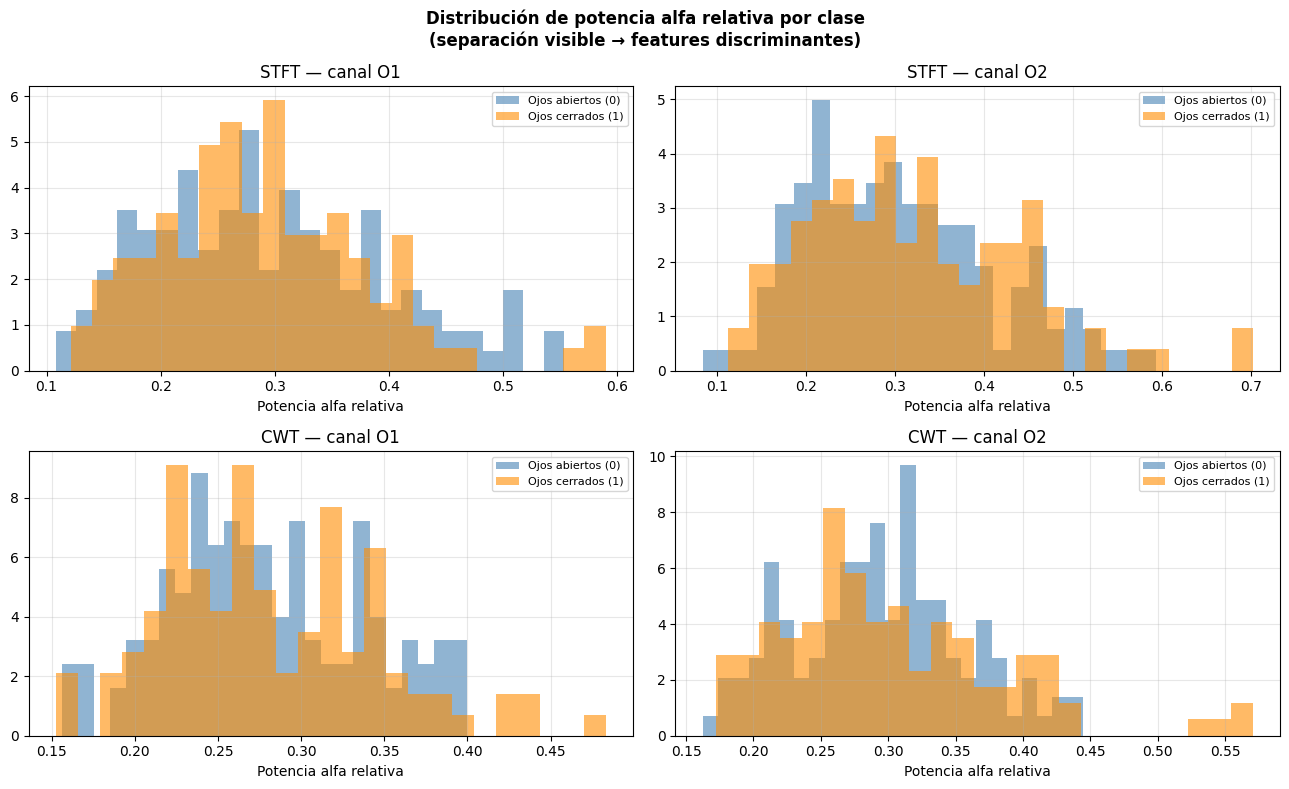


STFT — media potencia alfa relativa en O1:
  Clase 0: 0.2934
  Clase 1: 0.2919

CWT — media potencia alfa relativa en O1:
  Clase 0: 0.2792
  Clase 1: 0.2808


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=False)

for row_i, (method, df_feat) in enumerate([('STFT', df_stft_feat), ('CWT', df_cwt_feat)]):
    for col_j, ch in enumerate(['O1', 'O2']):
        ax = axes[row_i, col_j]
        col = f'{ch}_alpha_rel'
        for cls, color, lbl in [(0, 'steelblue', 'Ojos abiertos (0)'),
                                 (1, 'darkorange', 'Ojos cerrados (1)')]:
            vals = df_feat.loc[df_feat['label'] == cls, col]
            ax.hist(vals, bins=25, alpha=0.6, color=color, label=lbl, density=True)
        ax.set_title(f'{method} — canal {ch}')
        ax.set_xlabel('Potencia alfa relativa')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Distribución de potencia alfa relativa por clase\n'
             '(separación visible → features discriminantes)', fontweight='bold')
plt.tight_layout()
plt.show()

# Resumen numérico
for method, df_feat in [('STFT', df_stft_feat), ('CWT', df_cwt_feat)]:
    print(f"\n{method} — media potencia alfa relativa en O1:")
    for cls in [0, 1]:
        m = df_feat.loc[df_feat['label'] == cls, 'O1_alpha_rel'].mean()
        print(f"  Clase {cls}: {m:.4f}")

In [7]:
# Celda de diagnóstico — agregar al notebook
print("=== Verificación del pipeline ===")
print(f"STFT freqs: {stft_freqs.min():.2f} – {stft_freqs.max():.2f} Hz")
print(f"CWT  freqs: {cwt_freqs.min():.2f} – {cwt_freqs.max():.2f} Hz")

# ¿La señal tiene media ~0 como corresponde tras Z-score?
import pandas as pd
df_orig = pd.read_csv('./data/eeg_eye_state_clean.csv')
print(f"\nMedia O1 en señal preprocesada: {df_orig['O1'].mean():.4f}  (esperado: ~0)")
print(f"Std  O1 en señal preprocesada: {df_orig['O1'].std():.4f}   (esperado: ~1)")

# Distribución temporal de etiquetas
labels_all = df_orig['eyeDetection'].values
print(f"\nTotal muestras clase 0: {(labels_all==0).sum()}  ({100*(labels_all==0).mean():.1f}%)")
print(f"Total muestras clase 1: {(labels_all==1).sum()}  ({100*(labels_all==1).mean():.1f}%)")

=== Verificación del pipeline ===
STFT freqs: 4.00 – 40.00 Hz
CWT  freqs: 4.00 – 40.00 Hz

Media O1 en señal preprocesada: 0.0000  (esperado: ~0)
Std  O1 en señal preprocesada: 1.0000   (esperado: ~1)

Total muestras clase 0: 8257  (55.1%)
Total muestras clase 1: 6723  (44.9%)


## Diagnóstico: baja discriminabilidad de las features espectrales

### Hallazgo inicial

Al extraer las features con ventana deslizante de 2 s y 75% de solapamiento, la
potencia alfa relativa mostró medias prácticamente idénticas entre clases en los
canales occipitales O1 y O2 — e incluso con la dirección invertida respecto a lo
esperado fisiológicamente (ojos cerrados debería presentar **mayor** potencia alfa):

> STFT — O1:  Clase 0 (ojos abiertos) = 0.2934  |  Clase 1 (ojos cerrados) = 0.2919  
> CWT  — O1:  Clase 0 (ojos abiertos) = 0.2792  |  Clase 1 (ojos cerrados) = 0.2808

### Causa identificada: artefactos de parpadeo en la banda alfa

Al inspeccionar los escalogramas CWT se observan rayas verticales de alta energía
distribuidas a lo largo de todo el registro. Estas rayas son **artefactos de
parpadeo (eye blink artifacts)** — no actividad neuronal — generados por el
movimiento de los párpados y propagados al arreglo completo de electrodos.

El problema crítico es que estos artefactos inyectan energía en el rango de
**0.5–12 Hz**, solapándose directamente con la banda alfa (8–13 Hz). Como los
parpadeos ocurren en **ambas clases**, la contaminación afecta ambos estados de
forma similar, borrando la diferencia fisiológica real.

La winsorización eliminó los spikes más extremos ($\sim 10^5$ µV), pero los
artefactos de parpadeo residuales tienen amplitudes moderadas que sobreviven ese
recorte. La solución técnicamente correcta sería la remoción mediante ICA; sin
embargo, con un único sujeto y una sesión continua de 117 s, ICA es inestable
por la escasez de datos independientes.

### Intento de mejora: segmentación por bloques sostenidos

Como alternativa a ICA, se exploró una estrategia de **segmentación por bloques
sostenidos** en un notebook complementario (03b): extraer features únicamente
desde períodos donde el estado ocular se mantiene estable durante al menos 4 s,
descartando transiciones y períodos cortos.

Los resultados fueron:

- Se identificaron solo **12 bloques sostenidos** (7 clase 0, 5 clase 1),
  produciendo **42 instancias** totales — insuficiente para clasificación
  supervisada confiable.
- La dirección del efecto alfa **no mejoró** de forma consistente:

   > STFT — O1:  Clase 0 = 0.2939  |  Clase 1 = 0.2879  
   > CWT  — O1:  Clase 0 = 0.2769  |  Clase 1 = 0.2767

Esto confirma que el problema no es metodológico sino **inherente al dataset**:
con un único sujeto, hardware de consumo (Emotiv EPOC) y sin remoción de
artefactos oculares, el efecto de alpha blocking no es robusto ni recuperable
mediante estrategias de segmentación.

### Decisión final y su justificación

Para la etapa de clasificación se utilizarán las **232 ventanas deslizantes**
de este notebook, por dos razones:

1. **Suficiencia estadística**: 232 instancias permiten entrenamiento y evaluación
   con resultados mínimamente interpretables; 42 no.
2. **Validez de la comparación**: el objetivo central del proyecto no es demostrar
   que la potencia alfa discrimina per se, sino **comparar la capacidad
   discriminativa de STFT vs CWT** bajo las mismas condiciones. Si ambas producen
   features igualmente poco discriminativas, eso es un resultado válido — y
   explicar por qué (limitaciones del hardware y del preprocesamiento) constituye
   en sí mismo una contribución metodológica.

El data leakage derivado del 75% de solapamiento se controla aplicando un
**split temporal por bloques** en la clasificación: los primeros ~80 s se
destinan a entrenamiento y los últimos ~37 s a test, evitando que ventanas
casi idénticas queden simultáneamente en ambos conjuntos.

## Guardado

In [8]:
output_dir = './data/features/'

os.makedirs(output_dir, exist_ok=True)

df_stft_feat.to_csv('./data/features/features_stft.csv', index=False)
df_cwt_feat.to_csv('./data/features/features_cwt.csv',  index=False)

print(f"Guardado: features_stft.csv  — {df_stft_feat.shape}")
print(f"Guardado: features_cwt.csv   — {df_cwt_feat.shape}")
print(f"\nColumnas de features: {COL_NAMES[:8]} ... ({len(COL_NAMES)} total + label)")

Guardado: features_stft.csv  — (236, 57)
Guardado: features_cwt.csv   — (236, 57)

Columnas de features: ['AF3_alpha_abs', 'AF3_alpha_rel', 'AF3_entropy', 'AF3_cog', 'F7_alpha_abs', 'F7_alpha_rel', 'F7_entropy', 'F7_cog'] ... (56 total + label)
